# Penrose Graphical Notation: Tensor Diagrams

Penrose graphical notation turns tensor calculus into pictures. A tensor becomes a node, each index becomes a line, and connecting two lines means "sum over this shared index."

Roger Penrose developed this visual language for mathematical physics, where index-heavy equations can hide the structure of a calculation. The same diagram habit now appears in tensor networks, quantum information, automatic differentiation, and neural-network explanations.

That one visual rule is the same idea behind matrix multiplication, tensor networks, and many neural-network diagrams.

<details>
<summary>Big idea</summary>

Instead of writing a long expression like $A_{ij}x_j$, draw a matrix node with two legs and a vector node with one leg. Connect the matching $j$ legs. The open $i$ leg is the output.

</details>

## 1. Mental Model

Tensor notation is powerful, but index-heavy equations get noisy fast.

Penrose's visual language uses three rules:

- A **node** is a tensor: vector, matrix, or higher-order array.
- An **open line** is a free index that remains in the output.
- A **connected line** is a contracted index, meaning we sum over it.

For example:

$$
y_i = A_{ij}x_j
$$

means: connect the $j$ leg of $A$ to the $j$ leg of $x$, and leave the $i$ leg open.

<details>
<summary>Index hint</summary>

When an index appears twice, it is usually summed over. In diagrams, that repeated index becomes a connected internal edge.

</details>

## 2. Build the Diagram Objects

We will build a tiny tensor-diagram engine:

- `TensorBlock` stores a NumPy array and names for its indices.
- `TensorDiagram` stores tensor nodes and connected index lines.
- The diagram can generate an `einsum` equation from the graph.
- The same diagram can be plotted with NetworkX.

<details>
<summary>Implementation hint</summary>

`numpy.einsum` is perfect here because it already understands index notation. Our graph will generate the `einsum` string automatically.

</details>

**Object model.** Define `TensorBlock`, the named objects used by the next examples.


In [ ]:
from dataclasses import dataclass

import string

import matplotlib.pyplot as plt

import networkx as nx

import numpy as np

Port = tuple[str, str]

@dataclass(frozen=True)
class TensorBlock:
    name: str
    data: np.ndarray
    indices: tuple[str, ...]

    def __post_init__(self) -> None:
        if self.data.ndim != len(self.indices):
            raise ValueError("The number of index names must match the tensor rank.")
        if len(set(self.indices)) != len(self.indices):
            raise ValueError("Use unique index names inside one tensor block.")

    @property
    def shape_label(self) -> str:
        return "x".join(str(size) for size in self.data.shape) or "scalar"


**State model.** Define `DiagramResult`, the data structure the lesson will operate on.


In [ ]:
@dataclass(frozen=True)
class DiagramResult:
    equation: str
    output_indices: tuple[str, ...]
    value: np.ndarray


**State model.** Define `TensorDiagram`, the data structure the lesson will operate on.


In [ ]:
class TensorDiagram:
    def __init__(self):
        self.tensors: dict[str, TensorBlock] = {}
        self.connections: list[tuple[Port, Port]] = []

    def add_tensor(self, name: str, data: np.ndarray, indices: tuple[str, ...]) -> "TensorDiagram":
        if name in self.tensors:
            raise ValueError(f"Tensor {name} already exists.")
        self.tensors[name] = TensorBlock(name, np.asarray(data), indices)
        return self

    def connect(self, left_tensor: str, left_index: str, right_tensor: str, right_index: str) -> "TensorDiagram":
        left = (left_tensor, left_index)
        right = (right_tensor, right_index)
        self._validate_port(left)
        self._validate_port(right)
        if self._dimension(left) != self._dimension(right):
            raise ValueError(f"Cannot connect {left} and {right}: dimensions differ.")
        if left in self.connected_ports() or right in self.connected_ports():
            raise ValueError("Each port can be connected only once in this simple simulator.")
        self.connections.append((left, right))
        return self

    def connected_ports(self) -> set[Port]:
        return {port for connection in self.connections for port in connection}

    def free_ports(self) -> list[Port]:
        connected = self.connected_ports()
        return [port for port in self._ports() if port not in connected]

    def einsum_equation(self) -> tuple[str, tuple[str, ...]]:
        labels = iter(string.ascii_letters)
        port_labels: dict[Port, str] = {}

        for left, right in self.connections:
            label = next(labels)
            port_labels[left] = label
            port_labels[right] = label

        for port in self._ports():
            if port not in port_labels:
                port_labels[port] = next(labels)

        input_terms = []
        for tensor in self.tensors.values():
            input_terms.append("".join(port_labels[(tensor.name, index)] for index in tensor.indices))

        free_ports = self.free_ports()
        output_term = "".join(port_labels[port] for port in free_ports)
        output_indices = tuple(index for _, index in free_ports)
        return f"{','.join(input_terms)}->{output_term}", output_indices

    def evaluate(self) -> DiagramResult:
        equation, output_indices = self.einsum_equation()
        arrays = [tensor.data for tensor in self.tensors.values()]
        value = np.einsum(equation, *arrays)
        return DiagramResult(equation, output_indices, np.asarray(value))

    def _ports(self) -> list[Port]:
        return [
            (tensor.name, index)
            for tensor in self.tensors.values()
            for index in tensor.indices
        ]

    def _validate_port(self, port: Port) -> None:
        tensor_name, index = port
        if tensor_name not in self.tensors:
            raise ValueError(f"Unknown tensor: {tensor_name}")
        if index not in self.tensors[tensor_name].indices:
            raise ValueError(f"Tensor {tensor_name} has no index {index!r}.")

    def _dimension(self, port: Port) -> int:
        tensor_name, index = port
        tensor = self.tensors[tensor_name]
        return tensor.data.shape[tensor.indices.index(index)]


**Visual helper.** Define `draw_tensor_diagram`, which turns state into something students can inspect.


In [ ]:
def draw_tensor_diagram(diagram: TensorDiagram, title: str, ax=None) -> None:
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))

    graph = nx.Graph()
    tensor_nodes = list(diagram.tensors)
    open_nodes: list[str] = []

    for tensor in diagram.tensors.values():
        graph.add_node(tensor.name, label=f"{tensor.name}\n{tensor.shape_label}", kind="tensor")

    for left, right in diagram.connections:
        label = f"{left[1]}={right[1]}"
        graph.add_edge(left[0], right[0], label=label, kind="contracted")

    for tensor_name, index in diagram.free_ports():
        open_node = f"{tensor_name}:{index}"
        open_nodes.append(open_node)
        graph.add_node(open_node, label=index, kind="open")
        graph.add_edge(tensor_name, open_node, label=index, kind="free")

    pos = nx.spring_layout(graph, seed=11, k=1.15)
    nx.draw_networkx_edges(graph, pos, ax=ax, edge_color="#4B5563", width=1.8)
    nx.draw_networkx_nodes(
        graph,
        pos,
        nodelist=tensor_nodes,
        node_shape="s",
        node_color="#E9C46A",
        edgecolors="#1F2933",
        linewidths=1.2,
        node_size=1700,
        ax=ax,
    )
    nx.draw_networkx_nodes(
        graph,
        pos,
        nodelist=open_nodes,
        node_shape="o",
        node_color="#2A9D8F",
        edgecolors="#1F2933",
        linewidths=1.0,
        node_size=520,
        ax=ax,
    )
    labels = nx.get_node_attributes(graph, "label")
    edge_labels = nx.get_edge_attributes(graph, "label")
    nx.draw_networkx_labels(graph, pos, labels=labels, font_size=9, ax=ax)
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=8, ax=ax)
    ax.set_title(title)
    ax.axis("off")


**Helper functions.** Define `merge_diagram` so the later cells stay focused on behavior.


In [ ]:
def merge_diagram(diagram: TensorDiagram, output_name: str) -> TensorBlock:
    result = diagram.evaluate()
    return TensorBlock(output_name, result.value, result.output_indices)


## 3. Matrix-Vector Multiplication

Start with the equation:

$$
y_i = A_{ij}x_j
$$

The index $j$ appears twice, so it is contracted. The index $i$ remains open, so it becomes the output vector index.

Generated einsum: ba,a->b
Open output indices: ('i',)
Diagram result: [ 7. -2.]
NumPy A @ x  : [ 7. -2.]


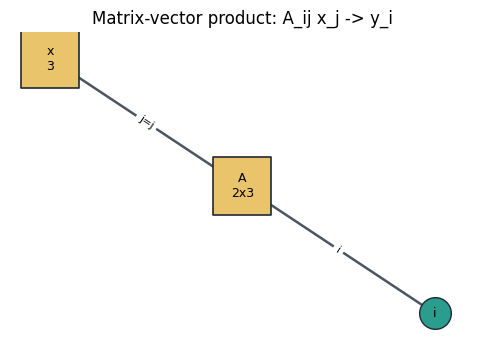

In [2]:
matrix_a = np.array([
    [2, 1, -1],
    [0, 3, 4],
], dtype=float)
vector_x = np.array([5, -2, 1], dtype=float)

matrix_vector_diagram = TensorDiagram()
matrix_vector_diagram.add_tensor("A", matrix_a, ("i", "j"))
matrix_vector_diagram.add_tensor("x", vector_x, ("j",))
matrix_vector_diagram.connect("A", "j", "x", "j")

matrix_vector_result = matrix_vector_diagram.evaluate()

print(f"Generated einsum: {matrix_vector_result.equation}")
print(f"Open output indices: {matrix_vector_result.output_indices}")
print("Diagram result:", matrix_vector_result.value)
print("NumPy A @ x  :", matrix_a @ vector_x)

draw_tensor_diagram(matrix_vector_diagram, "Matrix-vector product: A_ij x_j -> y_i")
plt.show()

## 4. Matrix Multiplication as Merging Nodes

For matrix multiplication:

$$
C_{ik} = A_{ij}B_{jk}
$$

The shared index $j$ is contracted. The open indices $i$ and $k$ become the two axes of the output matrix $C$.

In the diagram, computing the contraction is like merging the connected nodes into one new tensor node.

**Inspect the result.** Render the current state so the algorithm is easier to reason about.


In [ ]:
matrix_b = np.array([
    [1, 0],
    [2, -1],
    [3, 4],
], dtype=float)

matrix_product_diagram = TensorDiagram()

matrix_product_diagram.add_tensor("A", matrix_a, ("i", "j"))

matrix_product_diagram.add_tensor("B", matrix_b, ("j", "k"))

matrix_product_diagram.connect("A", "j", "B", "j")

matrix_product_result = matrix_product_diagram.evaluate()

merged_c = merge_diagram(matrix_product_diagram, "C")

merged_diagram = TensorDiagram()

merged_diagram.add_tensor("C", merged_c.data, merged_c.indices)

print(f"Generated einsum: {matrix_product_result.equation}")

print(f"Open output indices: {matrix_product_result.output_indices}")

print("Diagram result:")

print(matrix_product_result.value)

print("NumPy A @ B:")

print(matrix_a @ matrix_b)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

draw_tensor_diagram(matrix_product_diagram, "before: A and B connected on j", ax=axes[0])

draw_tensor_diagram(merged_diagram, "after: merged output tensor C", ax=axes[1])


**Inspect the result.** Render the current state so the algorithm is easier to reason about.


In [ ]:
plt.tight_layout()

plt.show()


## 5. Higher-Order Tensor Contraction

Graphical notation becomes more useful as tensor rank grows.

Here is a rank-3 tensor contracted with a vector:

$$
Y_{ac} = T_{abc}m_b
$$

The $b$ index disappears because it is connected. The $a$ and $c$ indices stay open.

Generated einsum: bac,a->bc
Open output indices: ('a', 'c')
Output shape: (2, 4)
Matches np.tensordot: True
[[12. 14. 16. 18.]
 [36. 38. 40. 42.]]


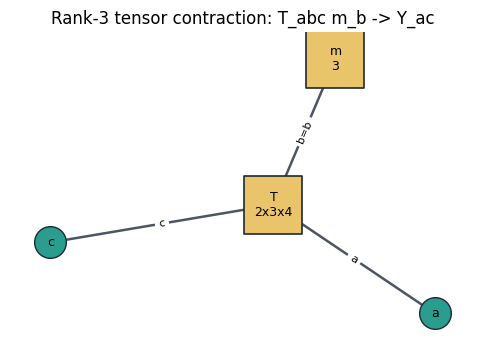

In [4]:
tensor_t = np.arange(2 * 3 * 4, dtype=float).reshape(2, 3, 4)
vector_m = np.array([1.0, -1.0, 2.0])

rank_three_diagram = TensorDiagram()
rank_three_diagram.add_tensor("T", tensor_t, ("a", "b", "c"))
rank_three_diagram.add_tensor("m", vector_m, ("b",))
rank_three_diagram.connect("T", "b", "m", "b")

rank_three_result = rank_three_diagram.evaluate()
manual_result = np.tensordot(tensor_t, vector_m, axes=([1], [0]))

print(f"Generated einsum: {rank_three_result.equation}")
print(f"Open output indices: {rank_three_result.output_indices}")
print(f"Output shape: {rank_three_result.value.shape}")
print("Matches np.tensordot:", np.allclose(rank_three_result.value, manual_result))
print(rank_three_result.value)

draw_tensor_diagram(rank_three_diagram, "Rank-3 tensor contraction: T_abc m_b -> Y_ac")
plt.show()

## 6. Replay the Diagrams

The diagrams and equations are two views of the same computation. This replay prints the tensor nodes, contracted ports, open ports, generated `einsum`, and result shape.

**Trace model.** Define `DiagramReplay`, the structure used to capture replayable algorithm state.


In [ ]:
class DiagramReplay:
    def __init__(self, diagrams: dict[str, TensorDiagram]):
        self.diagrams = diagrams

    def show(self) -> None:
        for name, diagram in self.diagrams.items():
            result = diagram.evaluate()
            tensor_labels = [
                f"{tensor.name}{tensor.indices}:{tensor.data.shape}"
                for tensor in diagram.tensors.values()
            ]
            connection_labels = [
                f"{left[0]}.{left[1]} -- {right[0]}.{right[1]}"
                for left, right in diagram.connections
            ]
            print(name)
            print("  tensors     :", "; ".join(tensor_labels))
            print("  contractions:", "; ".join(connection_labels) or "none")
            print("  open indices:", result.output_indices or "scalar")
            print("  einsum      :", result.equation)
            print("  result shape:", result.value.shape or "scalar")
            print()


**Inspect the result.** Evaluate the expression and read the output before changing parameters.


In [ ]:
DiagramReplay({
    "matrix-vector": matrix_vector_diagram,
    "matrix-product": matrix_product_diagram,
    "rank-3 contraction": rank_three_diagram,
}).show()


## 7. Neural Network Connection

A linear neural network layer is also tensor contraction.

For two layers without activation:

$$
y_k = W^{(2)}_{kh}W^{(1)}_{hi}x_i
$$

The feature index $i$ and hidden index $h$ are internal wires. The output index $k$ stays open.

**Example state.** Create `features`, `layer_one`, `layer_two`, `network_diagram`, and related helpers, the concrete values used in the next run.


In [ ]:
features = np.array([1.5, -2.0, 0.5])

layer_one = np.array([
    [0.8, -0.3, 0.4],
    [0.1, 0.9, -0.6],
    [-0.5, 0.2, 0.7],
    [0.3, 0.4, 0.2],
])

layer_two = np.array([
    [1.0, -0.4, 0.2, 0.5],
    [-0.2, 0.7, 0.6, -0.1],
])

network_diagram = TensorDiagram()

network_diagram.add_tensor("W1", layer_one, ("h", "i"))

network_diagram.add_tensor("x", features, ("i",))

network_diagram.add_tensor("W2", layer_two, ("k", "h"))

network_diagram.connect("W1", "i", "x", "i")

network_diagram.connect("W2", "h", "W1", "h")

network_result = network_diagram.evaluate()

manual_network_result = layer_two @ (layer_one @ features)

print(f"Generated einsum: {network_result.equation}")

print(f"Open output indices: {network_result.output_indices}")

print("Diagram output:", np.round(network_result.value, 4))


**Inspect the result.** Render the current state so the algorithm is easier to reason about.


In [ ]:
print("Manual W2 @ (W1 @ x):", np.round(manual_network_result, 4))

print("Matches manual computation:", np.allclose(network_result.value, manual_network_result))

draw_tensor_diagram(network_diagram, "Two-layer linear network as tensor contraction")

plt.show()


## 8. Playground: Scalar Contractions

If every index is connected, no open lines remain. The output is a scalar.

Two classic examples:

- Inner product: $u_i v_i$
- Trace: $M_{ii}$

<details>
<summary>Scalar hint</summary>

A scalar diagram has no free legs. In `einsum`, that means the output side after `->` is empty.

</details>

**Example state.** Create `vector_u`, `vector_v`, `inner_product_diagram`, `inner_product_result`, and related helpers, the concrete values used in the next run.


In [ ]:
vector_u = np.array([3.0, -2.0, 4.0])

vector_v = np.array([1.0, 5.0, -1.0])

inner_product_diagram = TensorDiagram()

inner_product_diagram.add_tensor("u", vector_u, ("i",))

inner_product_diagram.add_tensor("v", vector_v, ("i",))

inner_product_diagram.connect("u", "i", "v", "i")

inner_product_result = inner_product_diagram.evaluate()

trace_matrix = np.array([
    [2.0, 7.0, 1.0],
    [0.0, -3.0, 4.0],
    [5.0, 2.0, 6.0],
])

trace_diagram = TensorDiagram()

trace_diagram.add_tensor("M", trace_matrix, ("row", "col"))

trace_diagram.connect("M", "row", "M", "col")

trace_result = trace_diagram.evaluate()

print("Inner product")

print(f"  einsum: {inner_product_result.equation}")

print(f"  diagram value: {inner_product_result.value.item():.1f}")

print(f"  NumPy value  : {np.dot(vector_u, vector_v):.1f}")

print()

print("Trace")


**Inspect the result.** Render the current state so the algorithm is easier to reason about.


In [ ]:
print(f"  einsum: {trace_result.equation}")

print(f"  diagram value: {trace_result.value.item():.1f}")

print(f"  NumPy value  : {np.trace(trace_matrix):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

draw_tensor_diagram(inner_product_diagram, "inner product: u_i v_i -> scalar", ax=axes[0])

draw_tensor_diagram(trace_diagram, "trace: M_ii -> scalar", ax=axes[1])

plt.tight_layout()

plt.show()


## 9. What You Should Remember

- Penrose graphical notation replaces tensor indices with shapes and wires.
- Open wires are free indices that remain in the output.
- Connected wires are contracted indices that get summed over.
- Matrix multiplication, tensor contraction, traces, and neural-network layers all follow the same wire rule.
- A graph can generate the algebra: this notebook turns connections into `numpy.einsum` equations.

<details>
<summary>Course connection</summary>

This is another algorithmic lens: define objects, connect them with rules, evaluate the structure, and inspect the result. The picture and the equation are two forms of the same computation.

</details>

## Visual Trace + Rigor Studio

**Problem frame.** Represent tensor and matrix operations as diagrams.

**Interactive animation target.** Animate contraction by removing connected index wires and updating tensor shapes.

**Correctness handle.** Connected wires represent summed indices; free wires represent output axes.

**Complexity handle.** Contraction order can change cost by orders of magnitude.

**Failure mode to test.** A visually simple diagram may hide an expensive intermediate tensor.

**Studio task.** Draw two contraction orders for the same expression and compare intermediate sizes.


In [ ]:
from pathlib import Path
import sys

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "courseware").exists():
        sys.path.insert(0, str(candidate))
        break

from courseware import AlgorithmPlayer, AlgorithmTrace, TraceStep, render_trace_table

# Convert the implementation above into snapshots:
# trace = AlgorithmTrace("Topic trace")
# trace.append("start", {"your_state": ...}, "What changed?", invariant="What remains true?")
# AlgorithmPlayer(trace, your_renderer).display()
print("Use AlgorithmTrace to turn this notebook's algorithm into a step-by-step visual player.")
